# **Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

## **Load Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving House Price Prediction Dataset.csv to House Price Prediction Dataset.csv


In [ ]:
data = pd.read_csv('House Price Prediction Dataset.csv')

## **Data Exploring**

In [ ]:
data.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
data.shape

(2000, 10)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [ ]:
data.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


## **Data Cleaning**

In [ ]:
data.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [ ]:
data.duplicated().sum()

np.int64(0)

## **Data Preprocessing**

In [ ]:
# Label Encoding
le = LabelEncoder()
data['Location'] = le.fit_transform(data['Location'])

In [ ]:
data['Location'].value_counts()

,count
Location,
0,558
3,485
2,483
1,474


In [ ]:
data['Condition'].value_counts()

,count
Condition,
Fair,521
Excellent,511
Poor,507
Good,461


In [ ]:
data['Condition'] = le.fit_transform(data['Condition'])
data['Garage'] = le.fit_transform(data['Garage'])

## EDA

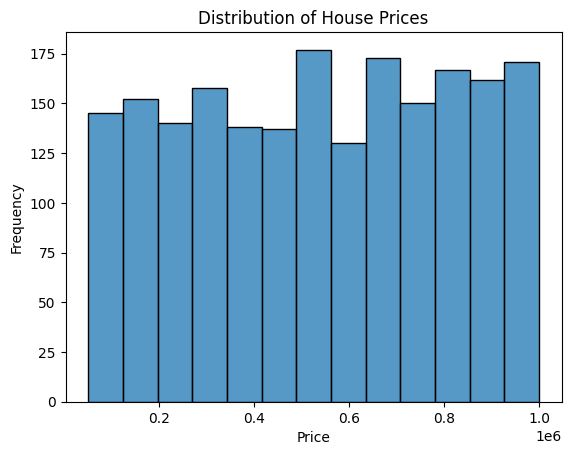

In [ ]:
sns.histplot(data=data, x='Price')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

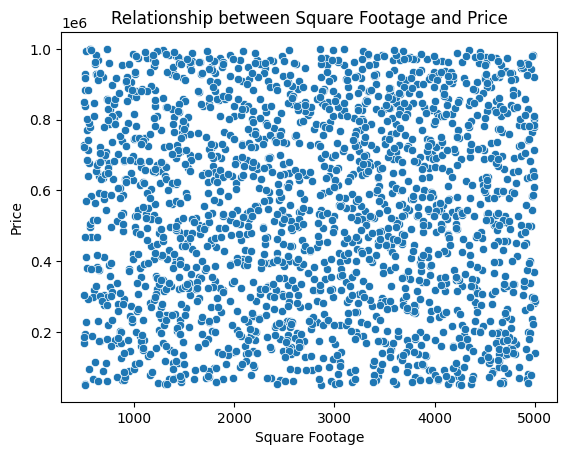

In [ ]:
sns.scatterplot(data=data, x='Area', y='Price')
plt.title('Relationship between Square Footage and Price')
plt.xlabel('Square Footage')
plt.ylabel('Price')
plt

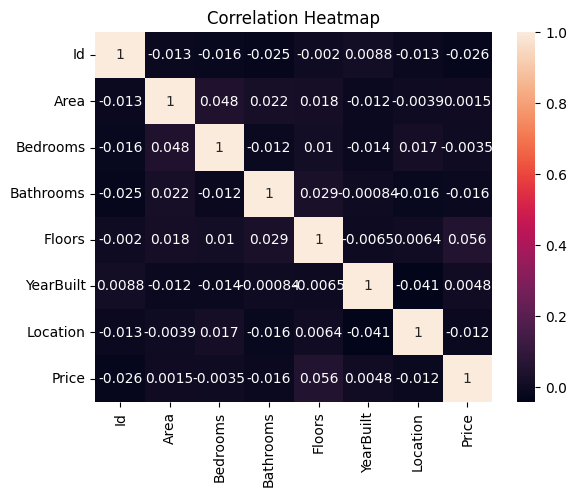

In [ ]:
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

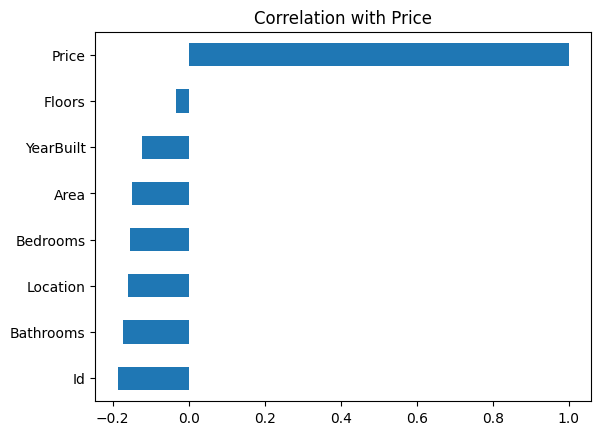

In [ ]:
data.select_dtypes(include='number').corr().corr()['Price'].sort_values().plot(kind='barh')
plt.title('Correlation with Price')
plt.show()

## **Train/Test Split**

In [ ]:
X = data.drop('Price', axis=1)
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_test.shape

(400, 9)

## **Scaling**

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## **Model Training**

In [ ]:
# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Gradient Boosting
model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

## **Evaluation**

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mean_absolute_error(y_test, y_pred)

245348.56453566178

In [ ]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(285083.7768739427)

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

-0.044652745843390296

## **Actual vs Predicted**

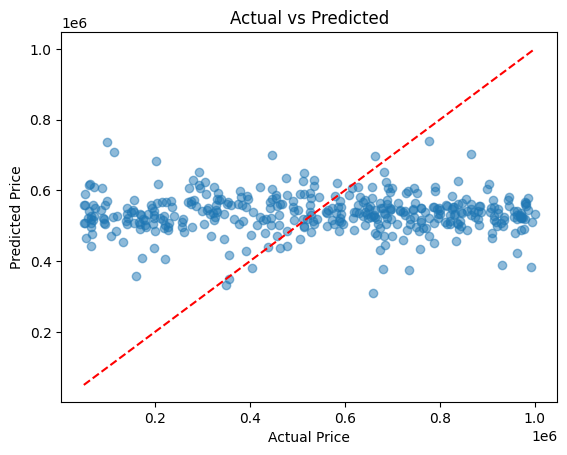

In [ ]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')
plt.show()